# Experiment: Roadrunner EGP Phase-60 T500 Non-Frac Fsed Sweep

Goal:

- Fix the planet/star condition at `T=500 K`, `a=5 AU`, `Rp=1.0 Rj`, `phase=60 deg`, and `g31`.
- Sweep every non-`frac` EGP thermal file available for this family: `NC`, `fsed0.3`, `fsed1`, `fsed3`, `fsed6`, and `fsed8`.
- Use Route C: `thermal_source="egp"` and `atmosphere_source="slgrid"`.
- Keep the selected SLGRID atmosphere fixed to the available exact non-`frac` `fsed3` PT/cloud pair for T500/g31.
- Reject any selected `frac10`, `frac25`, `frac50`, or `frac75` file.
- Produce a table and figure: reflected fraction vs EGP thermal fsed for CGI-1, CGI-2, CGI-3, and CGI-4.

The local T500 inventory has all six non-`frac` EGP IRflux files, but only the `fsed3` exact non-`frac` PT/cloud pair. This notebook therefore sweeps the EGP thermal fsed while holding the reflected/PICASO atmosphere at the available non-`frac` `fsed3` profile.

In [1]:
# Setup: PICASO4-local imports and paths
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=RuntimeWarning)

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

SEARCH_ROOTS = [Path.cwd(), *Path.cwd().parents]
SEARCH_ROOTS.append(Path("/Users/xin/Documents/Documents/College/aurora"))

for candidate in SEARCH_ROOTS:
    if (candidate / "roadrunner_egp" / "roadrunner").exists():
        REPO_ROOT = candidate.resolve()
        break
else:
    raise FileNotFoundError("Could not locate aurora/roadrunner_egp/roadrunner.")

ROADRUNNER_ROOT = REPO_ROOT / "roadrunner_egp"
SCIENCE_INPUTS = REPO_ROOT / "science_inputs"
RESULTS_DIR = ROADRUNNER_ROOT / "results" / "phase60_t500_a5_g31_fsed_sweep"
TMP_DIR = REPO_ROOT / "tmp"

for directory in (RESULTS_DIR, TMP_DIR / "matplotlib", TMP_DIR / "numba-cache"):
    directory.mkdir(parents=True, exist_ok=True)

# Force this notebook to use the Aurora data.
os.environ["ROADRUNNER_SCIENCE_INPUTS"] = str(SCIENCE_INPUTS)
os.environ["picaso_refdata"] = str(REPO_ROOT / "picaso4_reference")
os.environ["PYSYN_CDBS"] = str(REPO_ROOT / "picaso4_reference" / "stellar_grids")
os.environ["SLGRID_BASE_DIR"] = str(SCIENCE_INPUTS / "slgrid")
os.environ["SLGRID_PT_DIR"] = str(SCIENCE_INPUTS / "slgrid" / "climate")
os.environ["SLGRID_CLD_DIR"] = str(SCIENCE_INPUTS / "slgrid" / "clouds")
os.environ["EGP_IRFLUX_DIR"] = str(SCIENCE_INPUTS / "egp" / "irflux")
os.environ["MPLCONFIGDIR"] = str(TMP_DIR / "matplotlib")
os.environ["NUMBA_CACHE_DIR"] = str(TMP_DIR / "numba-cache")

if str(ROADRUNNER_ROOT) not in sys.path:
    sys.path.insert(0, str(ROADRUNNER_ROOT))

# Make repeated top-to-bottom notebook runs use the env vars above.
for module_name in list(sys.modules):
    if (
        module_name == "roadrunner"
        or module_name.startswith("roadrunner.")
        or module_name == "workflows.phase60_fsed_sweep"
        or module_name == "workflows.hybrid_reflected_picaso_thermal_egp"
    ):
        del sys.modules[module_name]

from workflows.phase60_fsed_sweep import (
    HAVE_PICASO,
    REFLECT_THRESHOLD,
    fsed_sweep_pivot,
    gravity_code_to_logg_cgs,
    phase60_fsed_file_inventory,
    plot_phase60_fsed_sweep,
    run_phase60_fsed_sweep,
)
from roadrunner.config import (
    CGI_BANDS,
    EGP_IRFLUX_DIR,
    LAM_GRID,
    SLGRID_CLD_DIR,
    SLGRID_PT_DIR,
)

print(f"Repo root: {REPO_ROOT}")
print(f"Notebook results: {RESULTS_DIR}")
print(f"PICASO available: {HAVE_PICASO}")
print(f"picaso_refdata: {os.environ['picaso_refdata']}")
print(f"PYSYN_CDBS: {os.environ['PYSYN_CDBS']}")
print(f"SLGRID climate: {SLGRID_PT_DIR}")
print(f"SLGRID clouds: {SLGRID_CLD_DIR}")
print(f"EGP IRflux: {EGP_IRFLUX_DIR}")
print(f"Wavelength grid: {LAM_GRID.min():.2f}-{LAM_GRID.max():.2f} um ({len(LAM_GRID)} pts)")
print(f"CGI bands: {list(CGI_BANDS.keys())}")

Repo root: /Users/dhuang/Documents/daniel/research/aurora
Notebook results: /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/phase60_t500_a5_g31_fsed_sweep
PICASO available: True
picaso_refdata: /Users/dhuang/Documents/daniel/research/aurora/picaso4_reference
PYSYN_CDBS: /Users/dhuang/Documents/daniel/research/aurora/picaso4_reference/stellar_grids
SLGRID climate: /Users/dhuang/Documents/daniel/research/aurora/science_inputs/slgrid/climate
SLGRID clouds: /Users/dhuang/Documents/daniel/research/aurora/science_inputs/slgrid/clouds
EGP IRflux: /Users/dhuang/Documents/daniel/research/aurora/science_inputs/egp/irflux
Wavelength grid: 0.30-1.00 um (1200 pts)
CGI bands: ['CGI-1', 'CGI-2', 'CGI-3', 'CGI-4']


## Fixed Run Configuration

This is a T500 phase-60 Route C fsed sweep. The swept variable is the non-`frac` EGP thermal case. The selected SLGRID atmosphere is fixed to `fsed3` because that is the only complete exact non-`frac` T500/g31 PT/cloud pair currently present.

In [2]:
TEMPERATURE_K = 500
GRAVITY_CODE = "31"
PLANNED_FSED_VALUES = ["NC", "0.3", "1", "3", "6", "8"]
ATMOSPHERE_FSED = "3"
METALLICITY = "+000"
CO_RATIO = "100"

PHASE_DEG = 60.0
R_PLANET_RJ = 1.0
SEMI_MAJOR_AU = 5.0

OUTPUT_CSV = RESULTS_DIR / "roadrunner_egp_phase60_T500_a5_g31_fsed_sweep.csv"
OUTPUT_PNG = RESULTS_DIR / "roadrunner_egp_phase60_T500_a5_g31_fsed_sweep.png"
MISSING_CSV = RESULTS_DIR / "roadrunner_egp_phase60_T500_a5_g31_fsed_missing_matching_atmosphere.csv"

config_summary = pd.DataFrame(
    [
        {"parameter": "temperature_k", "value": TEMPERATURE_K},
        {"parameter": "gravity_code", "value": GRAVITY_CODE},
        {"parameter": "logg_cgs", "value": round(gravity_code_to_logg_cgs(GRAVITY_CODE), 6)},
        {"parameter": "planned_egp_fsed_values", "value": PLANNED_FSED_VALUES},
        {"parameter": "selected_slgrid_atmosphere_fsed", "value": ATMOSPHERE_FSED},
        {"parameter": "metallicity", "value": METALLICITY},
        {"parameter": "co_ratio", "value": CO_RATIO},
        {"parameter": "phase_deg", "value": PHASE_DEG},
        {"parameter": "r_planet_rj", "value": R_PLANET_RJ},
        {"parameter": "semi_major_au", "value": SEMI_MAJOR_AU},
        {"parameter": "thermal_source", "value": "egp"},
        {"parameter": "atmosphere_source", "value": "slgrid"},
        {"parameter": "frac_allowed_in_selected_inputs", "value": False},
        {"parameter": "threshold", "value": REFLECT_THRESHOLD},
    ]
)

display(config_summary)

,parameter,value
0,temperature_k,500
1,gravity_code,31
2,logg_cgs,3.491362
3,planned_egp_fsed_values,"[NC, 0.3, 1, 3, 6, 8]"
4,selected_slgrid_atmosphere_fsed,3
5,metallicity,+000
6,co_ratio,100
7,phase_deg,60.0
8,r_planet_rj,1.0
9,semi_major_au,5.0


## Preflight: Selected Non-Frac Route C Inventory

`NC` is the zero cloud-fraction EGP thermal case. The `matching_atmosphere_exists` column shows whether a same-fsed T500 SLGRID PT/cloud pair exists. The selected run inputs use `selected_*` columns, which are fixed to the exact non-`frac` `fsed3` PT/cloud files.

In [3]:
file_inventory = phase60_fsed_file_inventory(
    temperature_k=TEMPERATURE_K,
    gravity_code=GRAVITY_CODE,
    fsed_values=PLANNED_FSED_VALUES,
    atmosphere_fsed=ATMOSPHERE_FSED,
    metallicity=METALLICITY,
    co_ratio=CO_RATIO,
)

selected_file_columns = ["selected_pt_file", "selected_cld_file", "egp_irflux_file"]
for column in selected_file_columns:
    frac_mask = file_inventory[column].str.contains("_frac", regex=False, na=False)
    if frac_mask.any():
        raise ValueError(f"Selected non-frac sweep file list contains frac file(s) in {column}.")

RUN_FSED_VALUES = file_inventory.loc[file_inventory["ready"], "fsed"].tolist()
missing_selected_inventory = file_inventory.loc[~file_inventory["ready"]].copy()
missing_matching_atmosphere = file_inventory.loc[~file_inventory["matching_atmosphere_exists"]].copy()

print(f"Planned EGP thermal cases: {PLANNED_FSED_VALUES}")
print(f"Runnable EGP thermal cases with fixed non-frac atmosphere: {RUN_FSED_VALUES}")

preflight_columns = [
    "fsed",
    "atmosphere_fsed",
    "matching_atmosphere_exists",
    "selected_pt_exists",
    "selected_pt_file",
    "selected_cld_exists",
    "selected_cld_file",
    "egp_irflux_exists",
    "egp_irflux_file",
    "ready",
]
display(file_inventory[preflight_columns])

if not missing_matching_atmosphere.empty:
    missing_matching_atmosphere.to_csv(MISSING_CSV, index=False)
    print(f"Saved missing matching-atmosphere report to: {MISSING_CSV}")
    display(
        missing_matching_atmosphere[
            [
                "fsed",
                "pt_exists",
                "pt_path",
                "cld_exists",
                "cld_path",
                "egp_irflux_exists",
                "egp_irflux_path",
                "selected_pt_file",
                "selected_cld_file",
            ]
        ]
    )

if missing_selected_inventory.empty:
    print("All selected non-frac run inputs are present.")
else:
    display(missing_selected_inventory[preflight_columns])
    raise FileNotFoundError("Missing selected non-frac run inputs; see preflight table above.")

assert RUN_FSED_VALUES == PLANNED_FSED_VALUES

Planned EGP thermal cases: ['NC', '0.3', '1', '3', '6', '8']
Runnable EGP thermal cases with fixed non-frac atmosphere: ['NC', '0.3', '1', '3', '6', '8']


,fsed,atmosphere_fsed,matching_atmosphere_exists,selected_pt_exists,selected_pt_file,selected_cld_exists,selected_cld_file,egp_irflux_exists,egp_irflux_file,ready
0,NC,3,False,True,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,True,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld,True,SLGRID_T500_g31_m+000_CO100_NC_IRflux.txt,True
1,0.3,3,False,True,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,True,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld,True,SLGRID_T500_g31_m+000_CO100_fsed0.3_IRflux.txt,True
2,1,3,False,True,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,True,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld,True,SLGRID_T500_g31_m+000_CO100_fsed1_IRflux.txt,True
3,3,3,True,True,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,True,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld,True,SLGRID_T500_g31_m+000_CO100_fsed3_IRflux.txt,True
4,6,3,False,True,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,True,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld,True,SLGRID_T500_g31_m+000_CO100_fsed6_IRflux.txt,True
5,8,3,False,True,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,True,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld,True,SLGRID_T500_g31_m+000_CO100_fsed8_IRflux.txt,True


Saved missing matching-atmosphere report to: /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/phase60_t500_a5_g31_fsed_sweep/roadrunner_egp_phase60_T500_a5_g31_fsed_missing_matching_atmosphere.csv


,fsed,pt_exists,pt_path,cld_exists,cld_path,egp_irflux_exists,egp_irflux_path,selected_pt_file,selected_cld_file
0,NC,False,/Users/dhuang/Documents/daniel/research/aurora...,True,,True,/Users/dhuang/Documents/daniel/research/aurora...,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld
1,0.3,False,/Users/dhuang/Documents/daniel/research/aurora...,False,/Users/dhuang/Documents/daniel/research/aurora...,True,/Users/dhuang/Documents/daniel/research/aurora...,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld
2,1,False,/Users/dhuang/Documents/daniel/research/aurora...,False,/Users/dhuang/Documents/daniel/research/aurora...,True,/Users/dhuang/Documents/daniel/research/aurora...,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld
4,6,False,/Users/dhuang/Documents/daniel/research/aurora...,False,/Users/dhuang/Documents/daniel/research/aurora...,True,/Users/dhuang/Documents/daniel/research/aurora...,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld
5,8,False,/Users/dhuang/Documents/daniel/research/aurora...,False,/Users/dhuang/Documents/daniel/research/aurora...,True,/Users/dhuang/Documents/daniel/research/aurora...,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld


All selected non-frac run inputs are present.


## Main Run

This cell runs one fixed phase-60 Route C case per EGP thermal fsed value and saves a combined CSV.

In [4]:
if not HAVE_PICASO:
    raise RuntimeError("PICASO is not available in this notebook kernel.")

sweep_df = run_phase60_fsed_sweep(
    teff_k=TEMPERATURE_K,
    rj=R_PLANET_RJ,
    a_au=SEMI_MAJOR_AU,
    gravity_code=GRAVITY_CODE,
    fsed_values=RUN_FSED_VALUES,
    atmosphere_fsed=ATMOSPHERE_FSED,
    phase_deg=PHASE_DEG,
    metallicity=METALLICITY,
    co_ratio=CO_RATIO,
)

sweep_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved detailed fsed-sweep results to: {OUTPUT_CSV}")
print(f"Rows: {len(sweep_df)}")

display(sweep_df)

Saved detailed fsed-sweep results to: /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/phase60_t500_a5_g31_fsed_sweep/roadrunner_egp_phase60_T500_a5_g31_fsed_sweep.csv
Rows: 24


,T_eff,logg,R_p_Rj,a_AU,phase_deg,band,f_reflect,Fp_ref_band,Fp_th_band,decision,gravity_code,fsed,fsed_numeric,atmosphere_fsed,pt_file,cld_file,egp_irflux_file
0,500.0,3.491362,1.0,5.0,60.0,CGI-1,0.826807,0.818757,0.171507,True,31,NC,0.0,3,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld,SLGRID_T500_g31_m+000_CO100_NC_IRflux.txt
1,500.0,3.491362,1.0,5.0,60.0,CGI-2,0.018466,1.186030,63.040220,False,31,NC,0.0,3,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld,SLGRID_T500_g31_m+000_CO100_NC_IRflux.txt
2,500.0,3.491362,1.0,5.0,60.0,CGI-3,0.005093,0.886794,173.243273,False,31,NC,0.0,3,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld,SLGRID_T500_g31_m+000_CO100_NC_IRflux.txt
3,500.0,3.491362,1.0,5.0,60.0,CGI-4,0.000168,0.475894,2833.806575,False,31,NC,0.0,3,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld,SLGRID_T500_g31_m+000_CO100_NC_IRflux.txt
4,500.0,3.491362,1.0,5.0,60.0,CGI-1,0.996834,0.818757,0.002600,True,31,0.3,0.3,3,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld,SLGRID_T500_g31_m+000_CO100_fsed0.3_IRflux.txt
5,500.0,3.491362,1.0,5.0,60.0,CGI-2,0.701797,1.186030,0.503961,True,31,0.3,0.3,3,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld,SLGRID_T500_g31_m+000_CO100_fsed0.3_IRflux.txt
6,500.0,3.491362,1.0,5.0,60.0,CGI-3,0.298951,0.886794,2.079555,True,31,0.3,0.3,3,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld,SLGRID_T500_g31_m+000_CO100_fsed0.3_IRflux.txt
7,500.0,3.491362,1.0,5.0,60.0,CGI-4,0.016188,0.475894,28.921320,False,31,0.3,0.3,3,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld,SLGRID_T500_g31_m+000_CO100_fsed0.3_IRflux.txt
8,500.0,3.491362,1.0,5.0,60.0,CGI-1,0.967406,0.818757,0.027585,True,31,1,1.0,3,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld,SLGRID_T500_g31_m+000_CO100_fsed1_IRflux.txt
9,500.0,3.491362,1.0,5.0,60.0,CGI-2,0.167782,1.186030,5.882826,True,31,1,1.0,3,SLGRID_T500_g31_m+000_CO100_fsed3_full.pt,SLGRID_T500_g31_m+000_CO100_fsed3_picaso.cld,SLGRID_T500_g31_m+000_CO100_fsed1_IRflux.txt


## Pivot Table And Main Figure

,fsed,fsed_numeric,CGI-1,CGI-2,CGI-3,CGI-4
0,NC,0.0,0.826807,0.018466,0.005093,0.000168
1,0.3,0.3,0.996834,0.701797,0.298951,0.016188
2,1,1.0,0.967406,0.167782,0.040530,0.002050
3,3,3.0,0.841449,0.023755,0.006293,0.000212
4,6,6.0,0.830276,0.020279,0.005494,0.000186
5,8,8.0,0.825648,0.019441,0.005290,0.000180


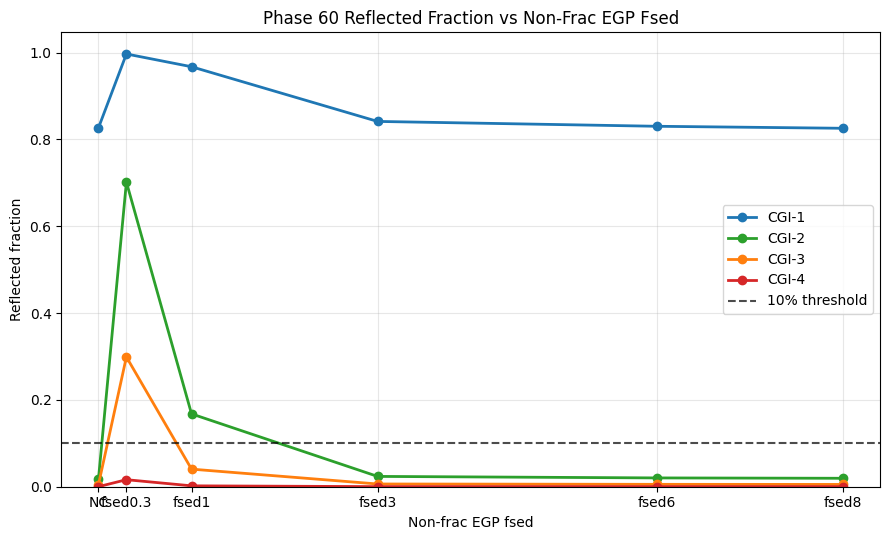

Saved fsed-sweep plot to: /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/phase60_t500_a5_g31_fsed_sweep/roadrunner_egp_phase60_T500_a5_g31_fsed_sweep.png


In [5]:
fsed_table = fsed_sweep_pivot(sweep_df)
display(fsed_table)

ax = plot_phase60_fsed_sweep(sweep_df)
plt.tight_layout()
ax.figure.savefig(OUTPUT_PNG, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved fsed-sweep plot to: {OUTPUT_PNG}")

## Validation

In [6]:
expected_rows = len(PLANNED_FSED_VALUES) * len(CGI_BANDS)
actual_fsed_values = list(sweep_df.sort_values("fsed_numeric")["fsed"].drop_duplicates())

assert len(sweep_df) == expected_rows, f"Expected {expected_rows} rows, got {len(sweep_df)}"
assert actual_fsed_values == PLANNED_FSED_VALUES, actual_fsed_values
assert sweep_df["gravity_code"].nunique() == 1
assert str(sweep_df["gravity_code"].iloc[0]) == GRAVITY_CODE
assert sweep_df["atmosphere_fsed"].nunique() == 1
assert str(sweep_df["atmosphere_fsed"].iloc[0]) == ATMOSPHERE_FSED
assert sweep_df["phase_deg"].nunique() == 1
assert float(sweep_df["phase_deg"].iloc[0]) == PHASE_DEG
assert sweep_df["T_eff"].nunique() == 1
assert float(sweep_df["T_eff"].iloc[0]) == float(TEMPERATURE_K)
assert sweep_df["a_AU"].nunique() == 1
assert float(sweep_df["a_AU"].iloc[0]) == float(SEMI_MAJOR_AU)
assert sweep_df["f_reflect"].notna().all()
assert not sweep_df["pt_file"].str.contains("_frac", regex=False).any()
assert not sweep_df["cld_file"].fillna("").str.contains("_frac", regex=False).any()
assert not sweep_df["egp_irflux_file"].str.contains("_frac", regex=False).any()
assert OUTPUT_CSV.exists()
assert OUTPUT_PNG.exists()

expected_irflux = {
    (
        f"SLGRID_T{TEMPERATURE_K}_g{GRAVITY_CODE}_m{METALLICITY}_CO{CO_RATIO}_NC_IRflux.txt"
        if fsed == "NC"
        else f"SLGRID_T{TEMPERATURE_K}_g{GRAVITY_CODE}_m{METALLICITY}_CO{CO_RATIO}_fsed{fsed}_IRflux.txt"
    )
    for fsed in PLANNED_FSED_VALUES
}
assert set(sweep_df["egp_irflux_file"].unique()) == expected_irflux

print("Validation passed for fixed-atmosphere T500 non-frac EGP fsed sweep.")

Validation passed for fixed-atmosphere T500 non-frac EGP fsed sweep.
